# Análise das exportações de Complexo Soja no RS (2015–2025)

Análise por Porto/URF seguindo o mesmo padrão dos notebooks anteriores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import re
from pathlib import Path

arquivo = "data_RS_Soja.xlsx"
produto_titulo = "Complexo Soja"
produto_titulo_minusculo = "complexo soja"
saida_imagem = "participacao_percentual_urf_complexo_soja.png"

# Mapeamento padronizado das URFs usadas nas análises
nomes_portos = {'1010252': '1010252 - JAGUARAO', '1010253': '1010253 - BAGE', '1010351': '1010351 - IRF SANTANA DO LIVRAMENTO', '1010900': '1010900 - URUGUAIANA', '1010953': '1010953 - SAO BORJA', '1015500': '1015500 - CHUI', '1015600': '1015600 - SANTANA DO LIVRAMENTO', '1017500': '1017500 - ALF - URUGUAIANA', '1017503': '1017503 - IRF - SÃO BORJA', '1017600': '1017600 - AEROPORTO SALGADO FILHO - PORTO ALEGRE', '1017700': '1017700 - PORTO DE RIO GRANDE', '1017701': '1017701 - IRF - CHUÍ', '1017800': '1017800 - ALF - PORTO ALEGRE', '1017801': '1017801 - IRF - AEROPORTO INTERNACIONAL SALGADO FILHO', '1017900': '1017900 - ALF - SANTANA DO LIVRAMENTO'}
ordem_urfs = list(nomes_portos.keys())


## 1. Carregamento e padronização da base

In [2]:
abas = pd.read_excel(arquivo, sheet_name=None)

lista_dfs = []
for nome_aba, df in abas.items():
    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df = df.copy()
        df["Codigo_URF"] = codigo
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

# Padronização numérica: os traços do arquivo indicam ausência de valor
for coluna in ["Peso_KG", "Valor_USD"]:
    base[coluna] = pd.to_numeric(base[coluna].replace("-", 0), errors="coerce").fillna(0)

base["Ano"] = pd.to_numeric(base["Ano"], errors="coerce")
base = base.dropna(subset=["Ano"]).copy()
base["Ano"] = base["Ano"].astype(int)

# Mantém apenas exportações, caso o arquivo tenha outras transações
if "Transacao" in base.columns:
    base = base[base["Transacao"].astype(str).str.lower().str.contains("exportacao|exportação", na=False)].copy()

base.head()


<cell 3>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
<cell 3>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,Agrupamento,Transacao,Ano,Produto,Regiao_UF_URF,Valor_USD,Peso_KG,Tipo_Local,Local,Codigo_URF,Porto_URF
0,Acordo Agrícola OMC e Pescados,Exportacao,2015,(1º Nível) COMPLEXO SOJA,(URF) 1010252 - JAGUARAO,2762880,3022512,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
1,Acordo Agrícola OMC e Pescados,Exportacao,2016,(1º Nível) COMPLEXO SOJA,(URF) 1010252 - JAGUARAO,2786845,3057825,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
2,Acordo Agrícola OMC e Pescados,Exportacao,2017,(1º Nível) COMPLEXO SOJA,(URF) 1010252 - JAGUARAO,2936497,3025544,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
3,Acordo Agrícola OMC e Pescados,Exportacao,2018,(1º Nível) COMPLEXO SOJA,(URF) 1010252 - JAGUARAO,2492453,2654331,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
4,Acordo Agrícola OMC e Pescados,Exportacao,2019,(1º Nível) COMPLEXO SOJA,(URF) 1010252 - JAGUARAO,2022768,2483128,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO


## 2. Resumo por Porto/URF

In [3]:
df_porto_ano = (
    base
    .groupby(["Ano", "Porto_URF"], as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"), Valor_USD=("Valor_USD", "sum"))
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

total_exportado_kg = base["Peso_KG"].sum()
total_exportado_milhoes = total_exportado_kg / 1_000_000

resumo_urf = (
    base
    .groupby("Porto_URF", as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"), Valor_USD=("Valor_USD", "sum"))
)
resumo_urf["Participacao_%"] = resumo_urf["Peso_KG"] / total_exportado_kg * 100
resumo_urf = resumo_urf.sort_values("Peso_KG", ascending=False)

print(f"Total exportado de {produto_titulo_minusculo}: {total_exportado_milhoes:,.2f} milhões de KG")
resumo_urf


Total exportado de complexo soja: 304,600.21 milhões de KG


,Porto_URF,Peso_KG,Valor_USD,Participacao_%
9,1017700 - PORTO DE RIO GRANDE,304463338922,129358800666,99.955065
0,1010252 - JAGUARAO,52540994,53728488,0.017249
10,1017701 - IRF - CHUÍ,34898968,39319910,0.011457
5,1015500 - CHUI,27344328,23581184,0.008977
7,1017500 - ALF - URUGUAIANA,9684264,10113918,0.003179
6,1015600 - SANTANA DO LIVRAMENTO,4106340,3801772,0.001348
12,1017900 - ALF - SANTANA DO LIVRAMENTO,3864930,3292910,0.001269
1,1010253 - BAGE,1956044,610374,0.000642
3,1010900 - URUGUAIANA,1553360,1594972,0.000510
8,1017503 - IRF - SÃO BORJA,780824,580678,0.000256


## 3. Evolução do peso exportado por Porto/URF

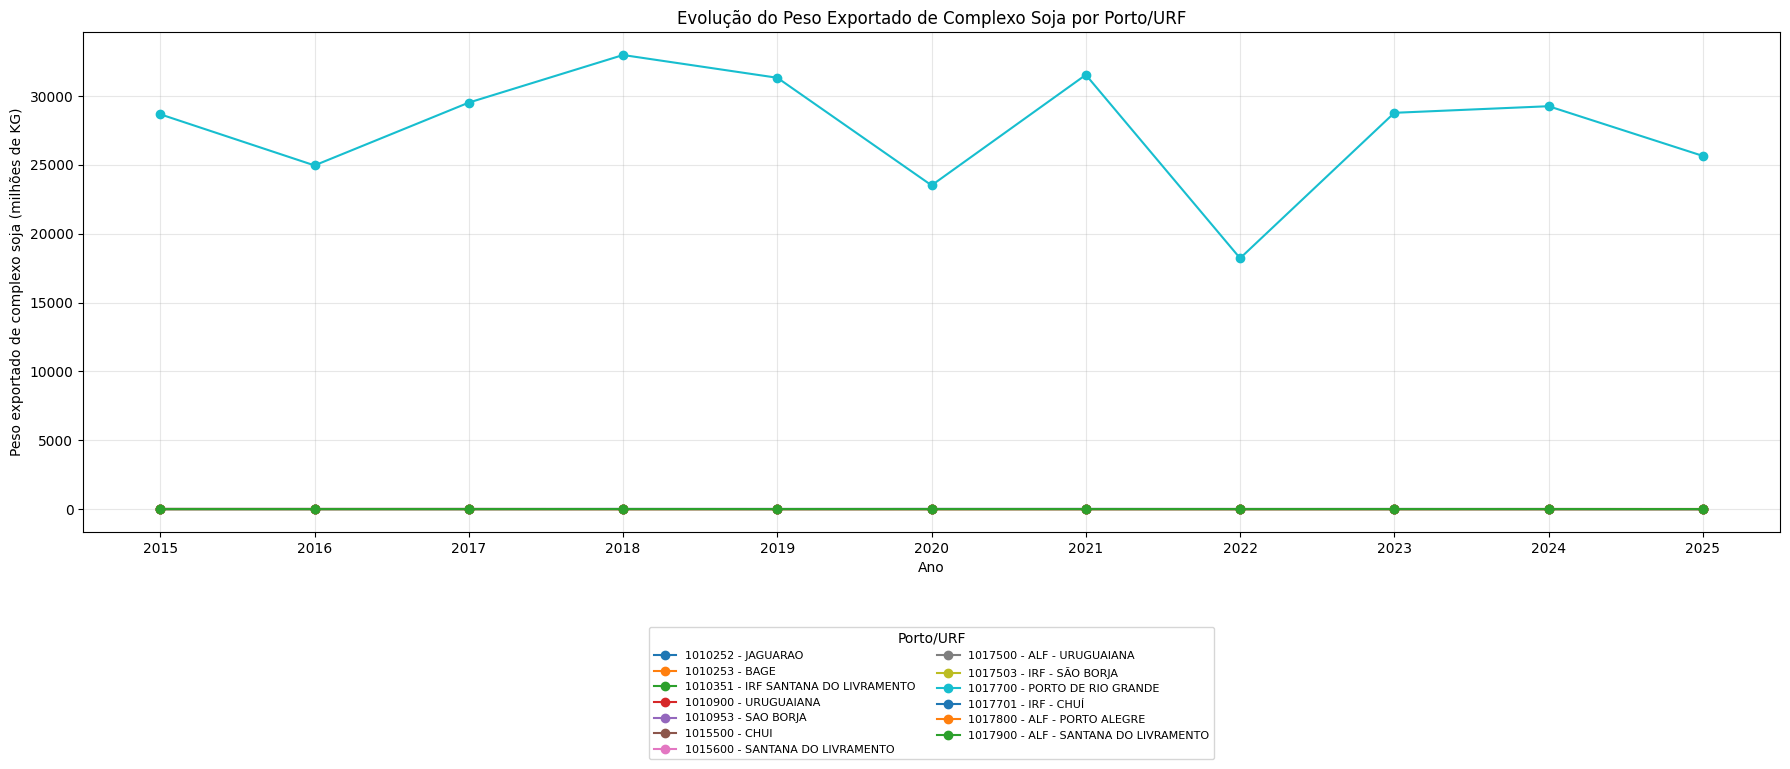

In [4]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title(f"Evolução do Peso Exportado de {produto_titulo} por Porto/URF")
plt.xlabel("Ano")
plt.ylabel(f"Peso exportado de {produto_titulo_minusculo} (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Evolução dos 3 maiores Portos/URFs

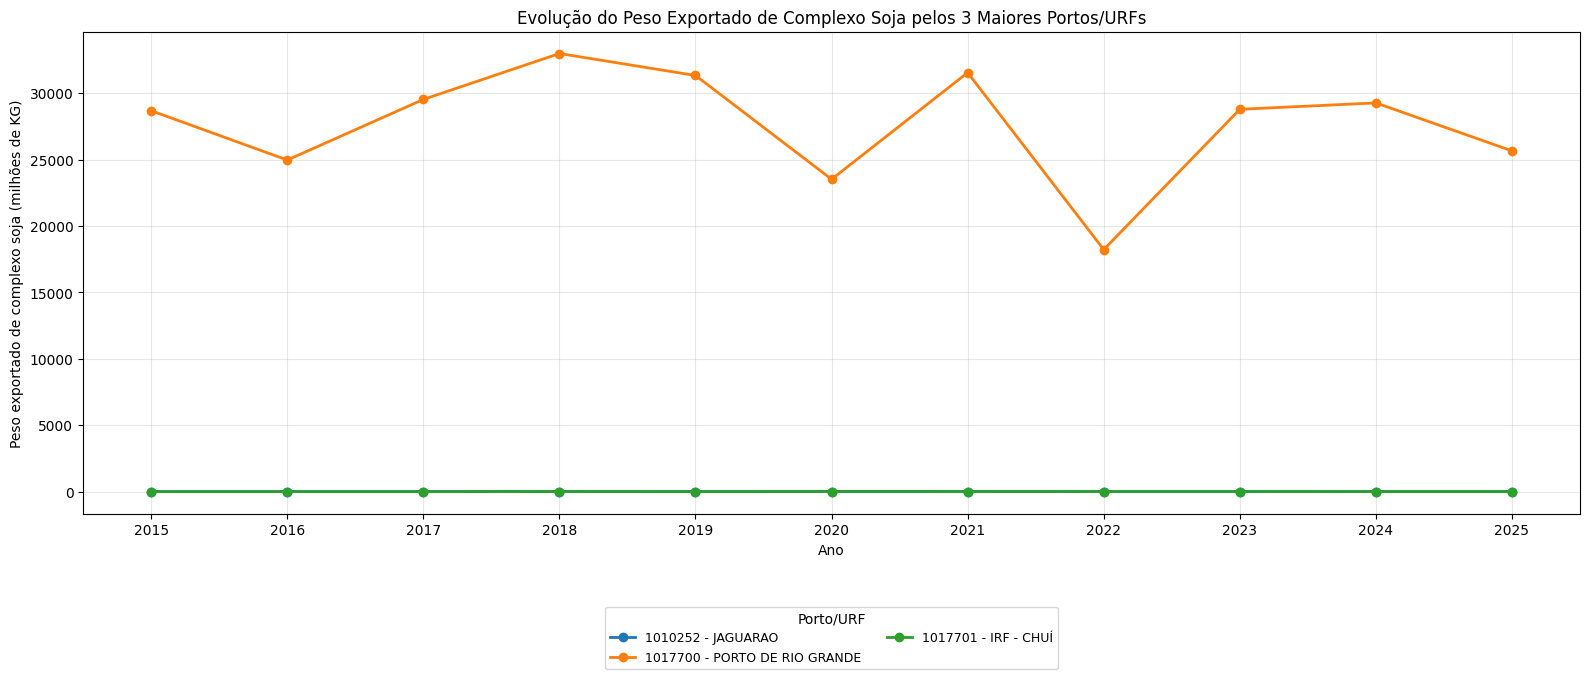

In [5]:
grafico = df_porto_ano.copy()

# Identificar os 3 maiores exportadores no total do período
top3_portos = (
    grafico
    .groupby("Porto_URF")["Peso_milhoes"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Filtrar apenas o Top 3
grafico_top3 = grafico[grafico["Porto_URF"].isin(top3_portos)]

# Criar tabela para o gráfico
tabela_grafico = grafico_top3.pivot_table(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 7))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        linewidth=2,
        label=porto
    )

plt.title(f"Evolução do Peso Exportado de {produto_titulo} pelos 3 Maiores Portos/URFs")
plt.xlabel("Ano")
plt.ylabel(f"Peso exportado de {produto_titulo_minusculo} (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=9
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Participação percentual por URF no total exportado

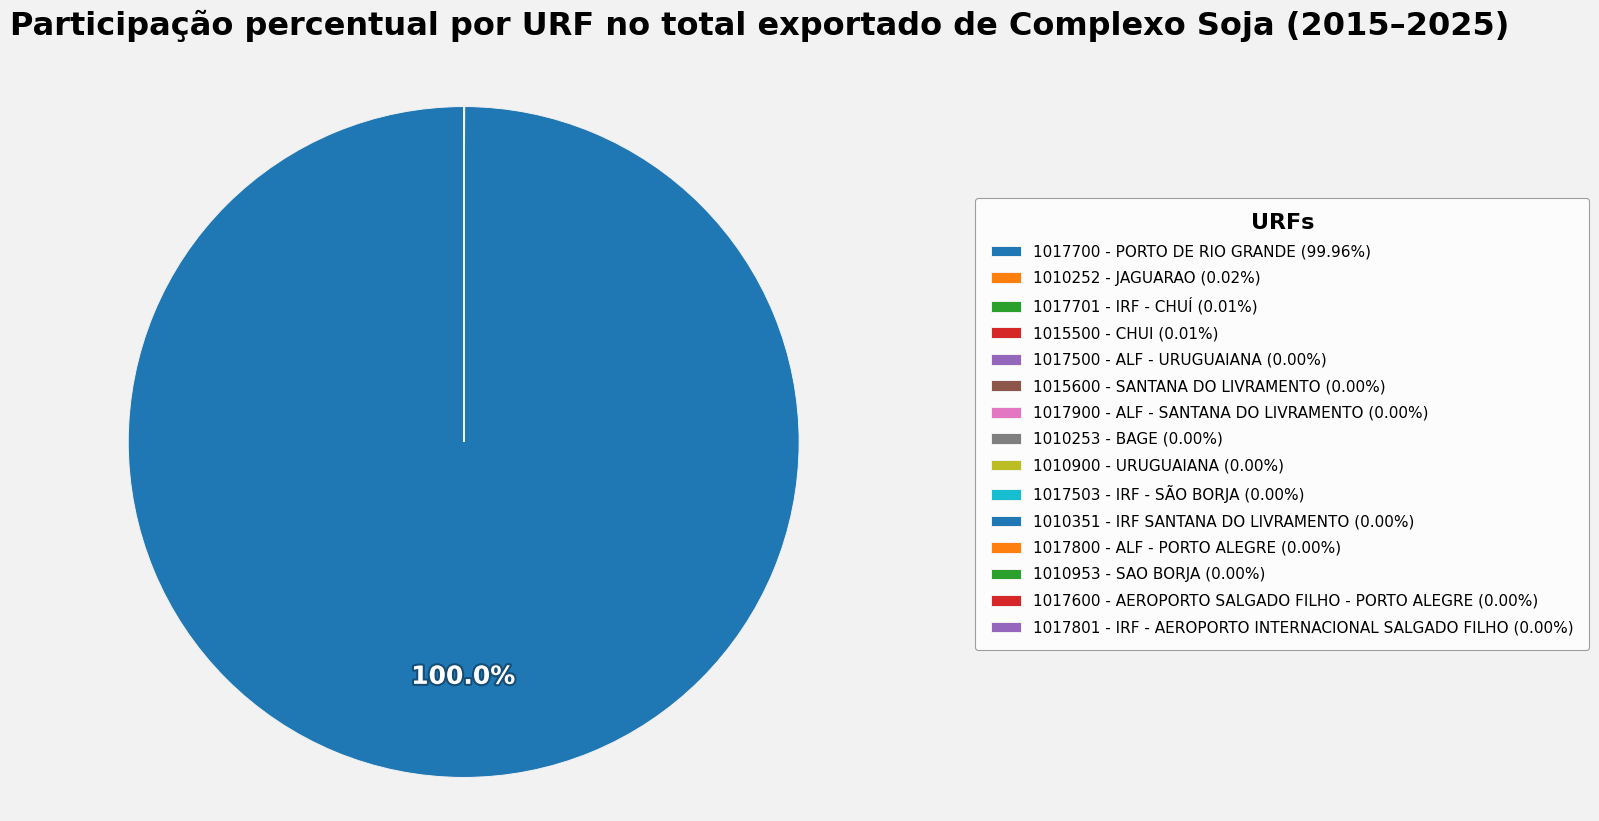

,Porto_URF,Peso_KG,Participacao_%
0,1017700 - PORTO DE RIO GRANDE,3.044633e+11,99.955065
1,1010252 - JAGUARAO,5.254099e+07,0.017249
2,1017701 - IRF - CHUÍ,3.489897e+07,0.011457
3,1015500 - CHUI,2.734433e+07,0.008977
4,1017500 - ALF - URUGUAIANA,9.684264e+06,0.003179
5,1015600 - SANTANA DO LIVRAMENTO,4.106340e+06,0.001348
6,1017900 - ALF - SANTANA DO LIVRAMENTO,3.864930e+06,0.001269
7,1010253 - BAGE,1.956044e+06,0.000642
8,1010900 - URUGUAIANA,1.553360e+06,0.000510
9,1017503 - IRF - SÃO BORJA,7.808240e+05,0.000256


In [6]:
# Tabela de participação, mantendo a lista padronizada de URFs mesmo quando alguma não aparece no arquivo
participacao = (
    base
    .groupby("Codigo_URF", as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"))
)

participacao_completa = pd.DataFrame({"Codigo_URF": ordem_urfs})
participacao_completa = participacao_completa.merge(participacao, on="Codigo_URF", how="left").fillna({"Peso_KG": 0})
participacao_completa["Porto_URF"] = participacao_completa["Codigo_URF"].map(nomes_portos)
participacao_completa["Participacao_%"] = participacao_completa["Peso_KG"] / total_exportado_kg * 100
participacao_completa = participacao_completa.sort_values("Participacao_%", ascending=False).reset_index(drop=True)

# Para desenhar categorias com 0, adiciona-se um valor visual mínimo, sem alterar os percentuais exibidos na legenda
valores_plot = participacao_completa["Peso_KG"].where(participacao_completa["Peso_KG"] > 0, 1e-9)
rotulos_legenda = [
    f"{linha['Porto_URF']} ({linha['Participacao_%']:.2f}%)"
    for _, linha in participacao_completa.iterrows()
]

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig = plt.figure(figsize=(16, 9), facecolor="#f2f2f2")
ax = fig.add_axes([0.04, 0.07, 0.55, 0.82], facecolor="#f2f2f2")

wedges, _, autotexts = ax.pie(
    valores_plot,
    startangle=90,
    autopct=autopct_func,
    pctdistance=0.70,
    wedgeprops={"linewidth": 0.7, "edgecolor": "#f2f2f2"},
    textprops={"color": "white", "fontsize": 18, "weight": "bold"},
)
ax.axis("equal")

for texto in autotexts:
    texto.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground="black", alpha=0.35),
        path_effects.Normal(),
    ])

fig.suptitle(
    f"Participação percentual por URF no total exportado de {produto_titulo} (2015–2025)",
    fontsize=23,
    fontweight="bold",
    y=0.96,
)

legenda = fig.legend(
    wedges,
    rotulos_legenda,
    title="URFs",
    loc="center left",
    bbox_to_anchor=(0.63, 0.50),
    frameon=True,
    fontsize=11,
    title_fontsize=16,
    borderpad=1.0,
    labelspacing=0.75,
)
legenda.get_title().set_fontweight("bold")
frame = legenda.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#888888")
frame.set_linewidth(0.8)

plt.savefig(saida_imagem, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

participacao_completa[["Porto_URF", "Peso_KG", "Participacao_%"]]


## 6. Resultado final

In [7]:
top3_resumo = resumo_urf.head(3).copy()
participacao_top3 = top3_resumo["Participacao_%"].sum()

print("Top 3 URFs no total exportado:")
for _, linha in top3_resumo.iterrows():
    print(f"- {linha['Porto_URF']}: {linha['Peso_KG'] / 1_000_000:.2f} milhões de KG ({linha['Participacao_%']:.2f}%)")

print(f"\nParticipação somada do Top 3: {participacao_top3:.2f}%")


Top 3 URFs no total exportado:
- 1017700 - PORTO DE RIO GRANDE: 304463.34 milhões de KG (99.96%)
- 1010252 - JAGUARAO: 52.54 milhões de KG (0.02%)
- 1017701 - IRF - CHUÍ: 34.90 milhões de KG (0.01%)

Participação somada do Top 3: 99.98%
